### Model 2 Preparation ###

This notebook prepares the dataset for the classification of gentrification alongside the protected areas in Berlin (Milieuschutz). 

In [8]:
#load libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

In [9]:
#Load the features 
X_df = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})

#load the label for Module 2
labels = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})

#join left on plr_id 
df = X_df.merge(labels[["plr_id", "milieu_majoritaet"]], on="plr_id", how="left")


In [10]:
#sanity check
df.shape


(527, 47)

In [11]:
#sanity check 2 
df.columns


Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_leerstandsquote', 're_brw_niveau', 're_brw_trend', 're_dichte_all',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_2024',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_households_without_minor_children_share_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benefit_share_change_2020_2024',
       'soc_single_parent_household_share_2024',
       'soc_single_parent_household_share_change_2021_2024',
       'com_median_age_level_2026', 'com_share_solo_level_2026',
       'com_share_10plus_le

In [12]:
#sanity check label

LABEL = "milieu_majoritaet"
assert df[LABEL].notna().all(), "Label enthält NaN — unerwartet."
assert set(df[LABEL].unique()) <= {0, 1}, "Label ist nicht binär 0/1."
print(df[LABEL].value_counts(), "\n")

milieu_majoritaet
0    418
1    109
Name: count, dtype: int64 



Good news: all dropped PLRs aren't protected. Therefore, 109 observations of protected PLRs stays. 

In [13]:
#define columns 
ID_COLS = ["plr_id", "plr_name", "bez"]   # bez = Gruppe, NICHT Feature
GROUP_COL = "bez"

#Guard for leakage: "milieu_anteil" should be the target, never the feature 
LEAKAGE_COLS = ["milieu_anteil"]

feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + [LABEL] + LEAKAGE_COLS
]
assert not any("milieu" in c for c in feature_cols), \
    "Label-abgeleitete Spalte im Feature-Set — Leakage!"

### 1) Log transformation checks of variables ###

In [14]:
#calculate skew to define the variables for log-transformation 
skew = df[feature_cols].skew().sort_values(ascending=False)
print("Skewness per feature (descending):\n")
print(skew.to_string())

#Rule of thumb: |skew| > 1 is clearly skewed -> variable for log-transformation 
#log only works for non-negative variables; exclude shares/trends as needed
log_candidates = skew[skew.abs() > 1].index.tolist()
print("\nCandidates (|skew| > 1):", log_candidates)



Skewness per feature (descending):

com_tourism_share_slope                                         14.511267
com_tourism_share_level_2026                                    11.429474
re_dichte_all                                                    3.822843
soc_internal_migration_volume_rate_2025                          3.763845
re_neubau_share                                                  3.556610
com_n_gastro                                                     2.963353
com_share_max_2y_slope                                           2.846477
soc_internal_migration_volume_rate_change_2021_2025              2.754792
com_share_solo_slope                                             2.332406
re_leerstandsquote                                               2.041133
re_brw_niveau                                                    1.924704
com_share_10plus_level_2026                                      1.828611
soc_single_parent_household_share_2024                           1.478141
co

In [15]:
#check whether the minimum values of the proposed variables for log transformation are all positive
proposed_log = [
    "com_tourism_share_level_2026",
    "re_dichte_all",
    "soc_internal_migration_volume_rate_2025",
    "re_neubau_share",
    "com_n_gastro",
    "re_leerstandsquote",
    "re_brw_niveau",
    "com_share_10plus_level_2026",
    "soc_single_parent_household_share_2024",
]

mins = df[proposed_log].min()
print("Minimum per proposed log feature:\n")
print(mins.to_string())

# Any negative minimum means log1p is invalid for that column -> drop it
invalid = mins[mins < 0].index.tolist()
print("\nNegative minimum (must NOT log):", invalid)

LOG_COLS = [c for c in proposed_log if c not in invalid]
print("\nFinal LOG_COLS:", LOG_COLS)

Minimum per proposed log feature:

com_tourism_share_level_2026                 0.000000
re_dichte_all                                0.000000
soc_internal_migration_volume_rate_2025      0.071000
re_neubau_share                              0.000000
com_n_gastro                                 0.000000
re_leerstandsquote                           0.361197
re_brw_niveau                              256.493697
com_share_10plus_level_2026                  0.000000
soc_single_parent_household_share_2024       0.022000

Negative minimum (must NOT log): []

Final LOG_COLS: ['com_tourism_share_level_2026', 're_dichte_all', 'soc_internal_migration_volume_rate_2025', 're_neubau_share', 'com_n_gastro', 're_leerstandsquote', 're_brw_niveau', 'com_share_10plus_level_2026', 'soc_single_parent_household_share_2024']


In [17]:
#confirmed, therefore log transform the proposed ones 

LOG_COLS = [
    "com_tourism_share_level_2026",
    "re_dichte_all",
    "soc_internal_migration_volume_rate_2025",
    "re_neubau_share",
    "com_n_gastro",
    "re_leerstandsquote",
    "re_brw_niveau",
    "com_share_10plus_level_2026",
    "soc_single_parent_household_share_2024",
]
LOG_COLS = [c for c in LOG_COLS if c in feature_cols]

print(f"\n{len(feature_cols)} features, of which {len(LOG_COLS)} were log transformed: {LOG_COLS}")



43 features, of which 9 were log transformed: ['com_tourism_share_level_2026', 're_dichte_all', 'soc_internal_migration_volume_rate_2025', 're_neubau_share', 'com_n_gastro', 're_leerstandsquote', 're_brw_niveau', 'com_share_10plus_level_2026', 'soc_single_parent_household_share_2024']


### 2. Prepare features, target and groups ###


In [18]:
#saveguard plr_id as string with 8 digits 
df["plr_id"] = df["plr_id"].astype(str).str.zfill(8)

X = df[feature_cols].copy()
y = df[LABEL].astype(int).to_numpy()           
groups = df[GROUP_COL].to_numpy()
plr_ids = df["plr_id"].to_numpy()

# Sanity-Checks 
assert len(X) == len(y) == len(groups) == len(plr_ids)
assert df["plr_id"].is_unique, "plr_id not unambiguous!"
n_pos = int(y.sum())
print(f"\nPositive: {n_pos} | Negative: {len(y) - n_pos} | positive rate: {n_pos/len(y):.1%}")



Positive: 109 | Negative: 418 | positive rate: 20.7%


### 3. Out of Fold loop (GroupKFold with Bezirk) ###

In [19]:
#Per fold: fit imputation + log + scaling on TRAIN only, apply to VAL

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

#build an OOF-Array to get one probability per PLR 
oof_prob = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train = X.iloc[train_idx].copy()
    X_val   = X.iloc[val_idx].copy()
    y_train = y[train_idx]

    #Missings' Imputation: fit on train, transform to both
    imputer = KNNImputer(n_neighbors=5)
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index
    )
    X_val_imp = pd.DataFrame(
        imputer.transform(X_val), columns=feature_cols, index=X_val.index
    )

    #Log-Transformation
    for col in LOG_COLS:
        X_train_imp[col] = np.log1p(X_train_imp[col])
        X_val_imp[col]   = np.log1p(X_val_imp[col])

    #Scaling: fit on train, transform to both for LogReg
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_val_scaled   = scaler.transform(X_val_imp)

    #Baseline model: fit on train predict_proba for val
    model = LogisticRegression(class_weight="balanced", max_iter=1000)
    model.fit(X_train_scaled, y_train)
    oof_prob[val_idx] = model.predict_proba(X_val_scaled)[:, 1]

    #fold diagnosis
    fold_ap = average_precision_score(y[val_idx], oof_prob[val_idx])
    print(f"Fold {fold}: n_val={len(val_idx):3d} | "
          f"Bezirke={np.unique(groups[val_idx])} | AUC-PR={fold_ap:.3f}")

#Check for full OOF-coverage 
assert not np.isnan(oof_prob).any(), "Not every PLR has an OOF prediction"

Fold 1: n_val= 96 | Bezirke=['03 - Pankow' '10 - Marzahn-Hellersdorf'] | AUC-PR=0.609
Fold 2: n_val= 92 | Bezirke=['04 - Charlottenburg-Wilmersdorf' '11 - Lichtenberg'] | AUC-PR=0.402
Fold 3: n_val=125 | Bezirke=['01 - Mitte' '09 - Treptow-Köpenick' '12 - Reinickendorf'] | AUC-PR=0.510
Fold 4: n_val= 91 | Bezirke=['05 - Spandau' '07 - Tempelhof-Schöneberg'] | AUC-PR=0.729
Fold 5: n_val=123 | Bezirke=['02 - Friedrichshain-Kreuzberg' '06 - Steglitz-Zehlendorf'
 '08 - Neukölln'] | AUC-PR=0.868


### 4. Results ###

In [21]:
oof_df = pd.DataFrame({
    "plr_id": plr_ids,
    "y_true": y,
    "oof_prob": oof_prob,
})

overall_ap = average_precision_score(y, oof_prob)
baseline_ap = y.mean()   
print(f"\nGesamt AUC-PR: {overall_ap:.3f}  (Baseline = {baseline_ap:.3f})")

oof_df.to_csv("../../models/M_oof_logreg.csv", index=False) 



Gesamt AUC-PR: 0.636  (Baseline = 0.207)


Result LogReg Model 

- AUC-PR 0.636, fold range 0.40–0.87 across districts
- fold range as the honesty caveat that doubles as a finding (districts gentrify unevenly)

The model identifies Milieuschutz patterns far above chance: AUC-PR 0.636 vs. a 0.207 baseline. It is a spatially honest prediction as the groupfold was done alongside the Bezirke-Variable. 

Looking at the spread, the model generalizes unevenly, and the pattern is interpretable: It's strongest where gentrification follows the inner-city template (Kreuzberg, Neukölln) and weakest where district dynamics differ (Charlottenburg's established affluence, Lichtenberg's eastern trajectory). This reframes variance as insight — different districts gentrify by different mechanisms — which is a genuinely interesting urban-studies claim your data supports.

#Choices / Decisions to be described
PU framing of a label that's really positive-only; spatially-honest CV; fold-wise preprocessing to prevent leakage; the hand-coded-vs-Cleanlab validation. 

In [22]:
#LogReg coefficients — magnitude + cross-fold stability

def preprocess_fit_transform(X_tr, X_ev, feature_cols, log_cols):
    """Fit impute+scale on X_tr, apply to both. Log is parameter-free."""
    imputer = KNNImputer(n_neighbors=5)
    Xtr = pd.DataFrame(imputer.fit_transform(X_tr), columns=feature_cols, index=X_tr.index)
    Xev = pd.DataFrame(imputer.transform(X_ev), columns=feature_cols, index=X_ev.index)
    for col in log_cols:
        Xtr[col] = np.log1p(Xtr[col])
        Xev[col] = np.log1p(Xev[col])
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xev_s = scaler.transform(Xev)
    return Xtr_s, Xev_s

#Per-fold coefficients for stability
fold_coefs = []
for train_idx, val_idx in gkf.split(X, y, groups):
    Xtr_s, _ = preprocess_fit_transform(
        X.iloc[train_idx], X.iloc[val_idx], feature_cols, LOG_COLS
    )
    m = LogisticRegression(class_weight="balanced", max_iter=1000)
    m.fit(Xtr_s, y[train_idx])
    fold_coefs.append(m.coef_[0])

#shape (5, n_features)
fold_coefs = np.array(fold_coefs) 

#One model refit on ALL rows for the headline ranking
X_all_s, _ = preprocess_fit_transform(X, X, feature_cols, LOG_COLS)
m_all = LogisticRegression(class_weight="balanced", max_iter=1000)
m_all.fit(X_all_s, y)

#results table includes full-data coefficient as the headline, stability: mean across folds, stability2: spread across folds
coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coef_all": m_all.coef_[0],            
    "coef_mean_fold": fold_coefs.mean(0),  
    "coef_std_fold": fold_coefs.std(0),    
})
coef_table["abs_coef"] = coef_table["coef_all"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False)

#Flag unstable signs: large effect but flips direction across folds
coef_table["sign_stable"] = (
    np.sign(coef_table["coef_mean_fold"]) == np.sign(coef_table["coef_all"])
) & (coef_table["coef_std_fold"] < coef_table["abs_coef"])

print(coef_table.to_string(index=False))

                                                     feature  coef_all  coef_mean_fold  coef_std_fold  abs_coef  sign_stable
            soc_households_without_minor_children_share_2024 -1.281842       -0.952981       0.256545  1.281842         True
                             soc_single_person_hh_share_2024  1.155249        0.975174       0.279296  1.155249         True
                      soc_single_parent_household_share_2024 -1.072388       -0.957705       0.138587  1.072388         True
                                             re_neubau_share -1.042873       -1.034908       0.196774  1.042873         True
                                               re_brw_niveau  0.926999        0.891355       0.169564  0.926999         True
                        soc_young_to_middle_adult_share_2025  0.877841        0.884368       0.249556  0.877841         True
                     soc_internal_migration_volume_rate_2025 -0.871534       -0.734316       0.177966  0.871534         True


HOW TO READ THE OUTPUT 

coef_all is your headline number per feature. Positive = pushes a PLR toward "looks like Milieuschutz"; negative = away. Because features are standardized, |coef| is comparable across features, so the top of the sorted table is your most influential variables.
coef_std_fold is the stability check. A feature with a big coef_all but a coef_std_fold of similar size is fragile — it's doing different things in different districts, so don't over-claim it.
sign_stable flags the ones you can describe confidently: large, and pointing the same direction in the full model and on average across folds.

TWO CAVEATS

First, sign can be counterintuitive under correlation. If two features are correlated (your Spearman check kept everything under |0.8| cross-dimension, so this is limited, but within-dimension pairs can still be moderate), LogReg can split the effect between them and even flip a sign. So read the top features as a set, not each in isolation — especially within the real-estate block where rent level, BRW level and Altbau share are related.
Second — and this connects to your whole framing — these coefficients describe what predicts designation, not what causes gentrification. A high positive coefficient on, say, Altbau share means "designated areas tend to have more Altbau," which is partly because Milieuschutz policy itself targets Altbau-heavy areas. So phrase it as "associated with Milieuschutz designation," not "drives gentrification." That distinction keeps the claim defensible.

WHERE TO PUT THE FOCUS NEXT

Performance: pooled AUC-PR + fold range + LogReg-vs-XGBoost. Don't rabbit-hole on hyperparameter tuning — untuned-but-honest is a fine capstone story, and tuning under GroupKFold is fiddly.
Feature analysis: top features by magnitude, stability flag, and the per-dimension rollup. Don't go deep on SHAP interaction plots now — one clean importance view per model is enough; fancy SHAP is next-week polish if time allows.
False positives: the ranked list, count, spatial pattern, and the milieu_anteil check. This is your centerpiece, so it earns the most depth — but it depends on XGBoost and Cleanlab being done first.

--> storyline: The model learns what Milieuschutz designation looks like (performance), the three dimensions tell us which signals define that pattern (features), and where the model confidently disagrees with the current designation map, we get an early-warning watchlist (false positives). 

In [23]:
#Per-dimension contribution: how much signal does each block carry?
coef_table["dim"] = coef_table["feature"].str[:3]  # 're_', 'soc', 'com'

dim_summary = coef_table.groupby("dim").agg(
    n_features=("feature", "count"),
    mean_abs_coef=("abs_coef", "mean"),
    sum_abs_coef=("abs_coef", "sum"),
    n_in_top10=("feature", lambda s: s.head(10).isin(
        coef_table.head(10)["feature"]).sum()),
).sort_values("mean_abs_coef", ascending=False)

print(dim_summary.to_string())

#How many of the top 10 features come from each dimension?
print("\nTop 10 features by |coef|, dimension breakdown:")
print(coef_table.head(10)["dim"].value_counts().to_string())

     n_features  mean_abs_coef  sum_abs_coef  n_in_top10
dim                                                     
soc          14       0.596576      8.352063           6
re_           8       0.434838      3.478701           2
com          21       0.241881      5.079504           2

Top 10 features by |coef|, dimension breakdown:
dim
soc    6
re_    2
com    2


Result 

Designated areas are characterized primarily by their current social composition — a demographic profile of single-person, childless, younger households with elevated transfer dependency — more than by their real-estate or commercial structure. Whether this composition is a cause of designation, a criterion for it, or a consequence of prior gentrification cannot be determined from this cross-sectional model.

COUNTERINTUITION 

The transfer_benefit_share being positive (+0.84) is the most counterintuitive result in the table. Naive gentrification intuition says "richer area." Instead, designated areas have more welfare dependency. That points away from "society has already changed (gentrified)" and toward "Milieuschutz is placed where a vulnerable population still exists and is worth protecting" — i.e. the policy targets areas at risk, before full transformation, not after. That's much closer to your project's actual thesis — early warning — than the "already changed" framing. It's worth a sentence in the writeup because it inverts the naive expectation and supports your premise.

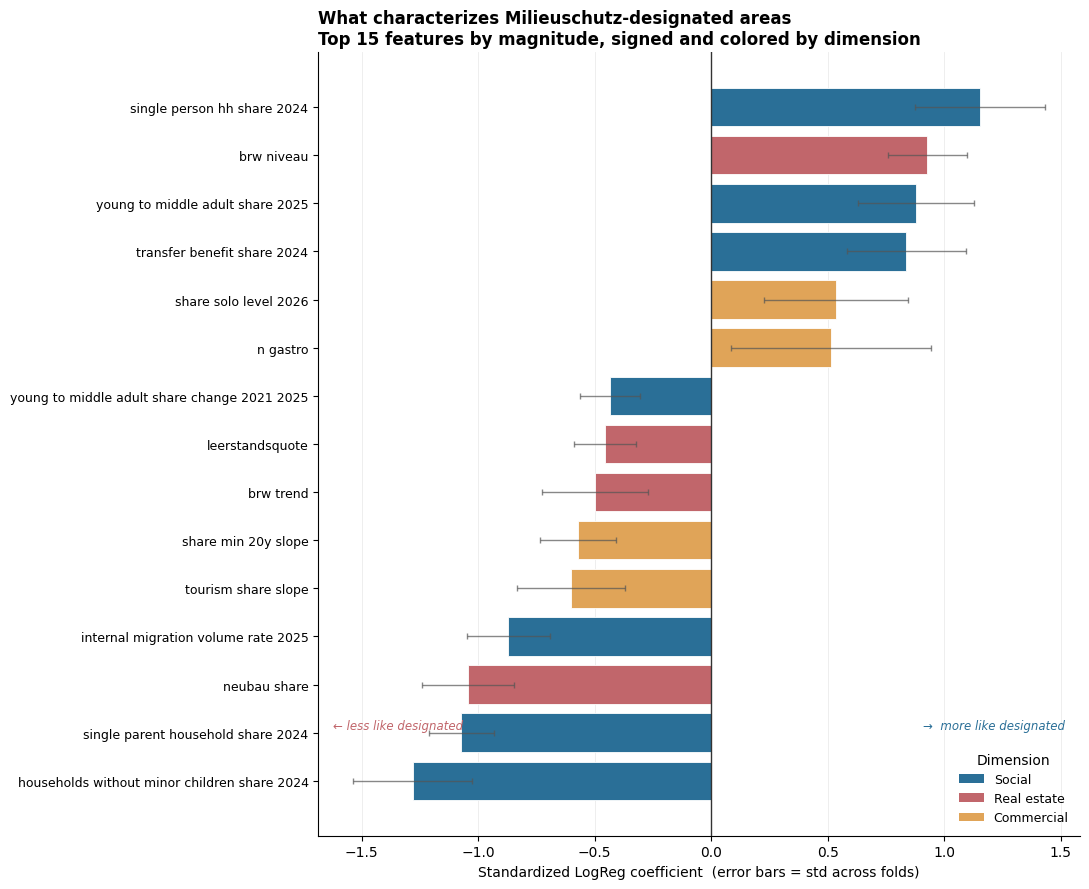

In [29]:
#Plot: LogReg coefficients — magnitude, direction, dimension, stability

TOP_N = 15

df = coef_table.copy()
df["dim"] = df["feature"].str[:3]                      # 'soc', 're_', 'com'
df = df.reindex(df["coef_all"].abs().sort_values(ascending=False).index)
df = df.head(TOP_N).sort_values("coef_all").reset_index(drop=True)

palette = {"soc": "#2A6F97", "re_": "#C1666B", "com": "#E0A458"}
labels  = {"soc": "Social", "re_": "Real estate", "com": "Commercial"}
colors  = df["dim"].map(palette)

def pretty(f):
    for p in ("soc_", "re_", "com_"):
        if f.startswith(p):
            f = f[len(p):]
    return f.replace("_", " ")
ylabels = df["feature"].apply(pretty)

fig, ax = plt.subplots(figsize=(11, 9))
y = np.arange(len(df))
ax.barh(y, df["coef_all"], xerr=df["coef_std_fold"], color=colors,
        edgecolor="white", linewidth=0.6,
        error_kw=dict(ecolor="#555555", lw=1, capsize=2.5, alpha=0.7))
ax.axvline(0, color="#333333", lw=1)
ax.set_yticks(y); ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel("Standardized LogReg coefficient  (error bars = std across folds)", fontsize=10)
ax.set_title("What characterizes Milieuschutz-designated areas\n"
             f"Top {TOP_N} features by magnitude, signed and colored by dimension",
             fontsize=12, fontweight="bold", loc="left")
ax.text(0.98, 1.01, "\u2192  more like designated", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=8.5, color="#2A6F97", style="italic", clip_on=False)
ax.text(0.02, 1.01, "\u2190 less like designated", transform=ax.get_yaxis_transform(),
        ha="left", va="bottom", fontsize=8.5, color="#C1666B", style="italic", clip_on=False)
legend = [Patch(facecolor=palette[k], label=labels[k]) for k in ["soc", "re_", "com"]]
ax.legend(handles=legend, loc="lower right", frameon=False, fontsize=9, title="Dimension")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../../plots/logreg_coefficients.png", dpi=200, bbox_inches="tight")  # adjust path
plt.show()
